In [74]:
import pandas as pd
from matplotlib import pyplot as cm
from PIL import Image, ImageDraw
from pathlib import Path

def annotate_image_with_predictions(
    img, predictions, likelihood_threshold, skeleton_color
):
    """
    Annotates an image with dots at specific points.
    Args:
        root_dir (str): Path to the directory containing image files.
        image_path (str): Path to the image file relative to root_dir.
        predictions (pd.Dataframe): A pandas dataframe where index = keypoint
                                    and columns are x, y, likelihood
                                    representing the points.
    """
    draw = ImageDraw.Draw(img)

    # Use a colormap to get consistent colors
    colormap = cm.get_cmap("tab20")  # You can choose any colormap you like

    # Draw dots on the image
    for i, (keypoint, (x,y,likelihood)) in enumerate(predictions.iterrows()):
        # Skip points below the threshold
        if likelihood < likelihood_threshold:
            continue
        color = tuple(
            int(c * 255) for c in colormap(i)[:3]
        )  # Get RGB color from colormap
        draw.ellipse(
            (x - 2, y - 2, x + 2, y + 2), fill=color
        )  # Draw a dot with radius 2

    # TODO read from a file?
    skeleton = [
        ("botBeak", "topBeak"),
        ("topBeak", "topHead"),
        ("topHead", "rightEye"),
        ("topHead", "leftEye"),
        ("topHead", "backHead"),
        ("backHead", "centerBack"),
        ("centerBack", "leftWing"),
        ("centerBack", "rightWing"),
        ("centerBack", "baseTail"),
        ("baseTail", "tipTail"),
        ("centerBack", "leftAnkle"),
        ("centerBack", "rightAnkle"),
        ("leftAnkle", "leftFoot"),
        ("rightAnkle", "rightFoot"),
    ]
    for keypoint1, keypoint2 in skeleton:
        pred1 = predictions.loc[keypoint1]
        pred2 = predictions.loc[keypoint2]
        x1, y1, likelihood1 = pred1.x, pred1.y, pred1.likelihood
        x2, y2, likelihood2 = pred2.x, pred2.y, pred2.likelihood
        if min(likelihood1, likelihood2) < likelihood_threshold:
            continue
        draw.line([(x1, y1), (x2, y2)], fill=skeleton_color, width=3)


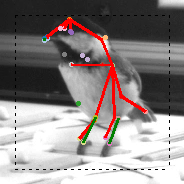

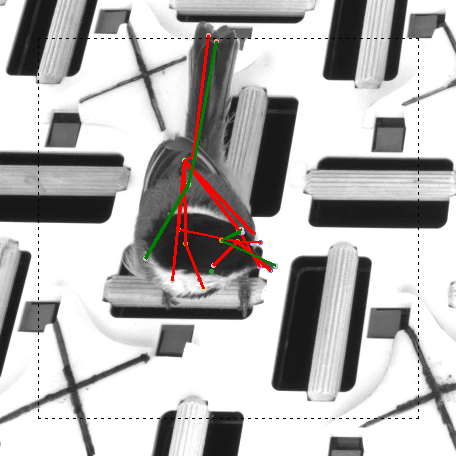

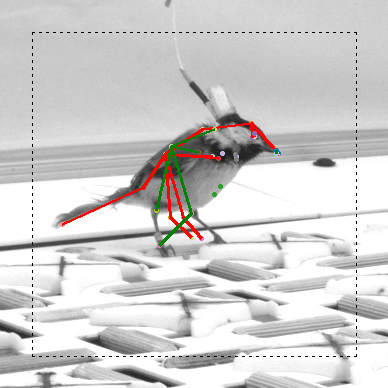

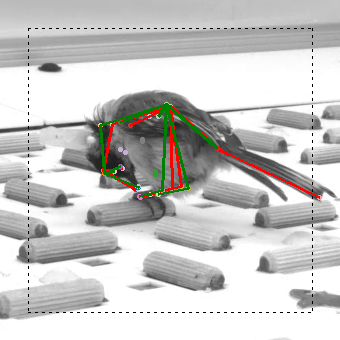

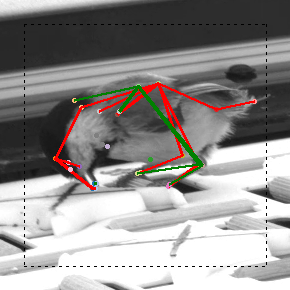

In [79]:
data_dir = "/mnt/d/LightningPoseData/chickadee"
single_preds_file = "fuse_outputs/chickadee/single_0/image_preds/CollectedData_merged.csv/predictions.csv"
pose_preds_file = "fuse_outputs/chickadee/pose_0/image_preds/cropped_CollectedData_merged.csv/remapped_predictions.csv"
bbox_file = "fuse_outputs/chickadee/single_0/image_preds/CollectedData_merged.csv/bbox.csv"

def read_preds_file(preds_file):
    preds_df = pd.read_csv(preds_file, header=[0, 1, 2], index_col=0)
    preds_df = preds_df.droplevel(level=0, axis=1) # axis=1 for columns
    preds_df = preds_df.loc[
        :, preds_df.columns.get_level_values(1).isin(["x", "y", "likelihood"])
    ]
    return preds_df

bbox_df = pd.read_csv(bbox_file, header=[0], index_col=0)

single_preds_df = read_preds_file(single_preds_file)
pose_preds_df = read_preds_file(pose_preds_file)
assert set(single_preds_df.index) == set(pose_preds_df.index)
assert set(bbox_df.index) == set(pose_preds_df.index)

def draw_bbox(img, bbox):
    draw = ImageDraw.Draw(img)
    x0, y0, x1, y1 = bbox.x, bbox.y, bbox.x + bbox.w, bbox.y + bbox.h

    color = 'black'
    dot_spacing = 5
    dot_length = 2

    # Clip bbox to image boundaries
    x0 = max(0, x0)
    y0 = max(0, y0)
    x1 = min(img.width, x1)
    y1 = min(img.height, y1)

    # Draw top and bottom lines
    for x in range(x0, x1, dot_spacing + dot_length):
        draw.line([(x, y0), (min(x + dot_length, x1), y0)], fill=color) #min to prevent going over the limit
        draw.line([(x, y1), (min(x + dot_length, x1), y1)], fill=color)

    # Draw left and right lines
    for y in range(y0, y1, dot_spacing + dot_length):
        draw.line([(x0, y), (x0, min(y+dot_length, y1))], fill=color)
        draw.line([(x1, y), (x1, min(y+dot_length, y1))], fill=color)

    padding = int(bbox.w * .10)
    x0_pad = max(0, x0 - padding)
    y0_pad = max(0, y0 - padding)
    x1_pad = min(img.width, x1 + padding)
    y1_pad = min(img.height, y1 + padding)

    return img.crop((x0_pad, y0_pad, x1_pad, y1_pad))


for img_path in single_preds_df.sample(n=5).index:
    red_preds = single_preds_df.loc[img_path].unstack(level=1)
    green_preds = pose_preds_df.loc[img_path].unstack(level=1)
    bbox = bbox_df.loc[img_path]

    abs_img_path = Path(data_dir) / img_path
    img = Image.open(abs_img_path)
    annotate_image_with_predictions(img, red_preds, 0.9, 'red')
    annotate_image_with_predictions(img, green_preds, 0.9, 'green')

    img = draw_bbox(img, bbox)

    display(img)
